# EDA of the eSEEd_v2 emotion dataset

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import time


## Prepare dataset
- load
- clean

In [22]:
data_dir = "../../data/processed/eSEEd_v2_processed/"

In [23]:
# load eseed dataset
def load_eseed_dataset(data_dir):
    strat_time = time.time()
    df = pd.DataFrame()
    for csv_file in os.listdir(data_dir):
        if csv_file.endswith(".csv"):
            df_part = pd.read_csv(os.path.join(data_dir, csv_file))
            df = pd.concat([df, df_part], ignore_index=True)
    print(f"Loaded eSEEd dataset in {time.time() - strat_time:.2f} seconds.")
    return df


In [24]:
df = load_eseed_dataset(data_dir)
dfOG = df.copy()  # keep original for comparison

Loaded eSEEd dataset in 10.01 seconds.


In [25]:
# put subject and recording columns first
cols = df.columns.tolist()
cols.insert(0, cols.pop(cols.index("subject")))
cols.insert(1, cols.pop(cols.index("recording")))
df = df[cols]


In [26]:
df.columns

Index(['subject', 'recording', 'time-rel-seconds', 'x-avg', 'y-avg',
       'confidence-gaze-left', 'confidence-gaze-right', 'pupil-size-left-avg',
       'pupil-size-right-avg', 'emotion-anger', 'emotion-tenderness',
       'emotion-sadness', 'emotion-disgust'],
      dtype='object')

In [27]:
# clean df
print(len(df[df["x-avg"] < 0]) / len(df))
print(len(df[df["x-avg"] > 1]) / len(df))
print(len(df[df["y-avg"] < 0]) / len(df))
print(len(df[df["y-avg"] > 1]) / len(df))
df = df[df["x-avg"].isna() | ((df["x-avg"] >= 0) & (df["x-avg"] <= 1) & (df["y-avg"] >= 0) & (df["y-avg"] <= 1))]

print(len(df[df["pupil-size-right-avg"] > 10]) / len(df))
print(len(df[df["pupil-size-left-avg"] > 10]) / len(df))
df = df[df["pupil-size-right-avg"].isna() | ((df["pupil-size-right-avg"] < 10) & (df["pupil-size-left-avg"] < 10))]

0.0002889240427747809
0.0005080272096919555
0.0009266603272817038
0.0004478468731787049
0.0020329052018198393
0.000588857654198318


## Plot distributions of raw signals per emotion
Signals: x, y, pupil size

['emotion-anger', 'emotion-tenderness', 'emotion-sadness', 'emotion-disgust']


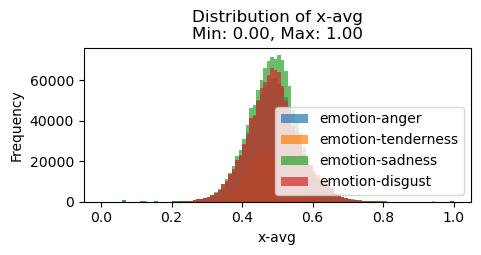

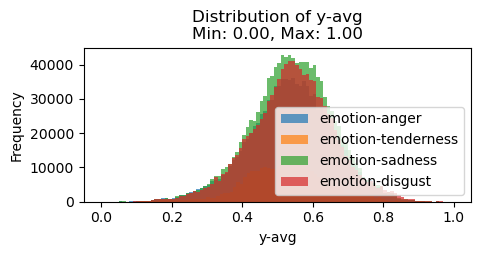

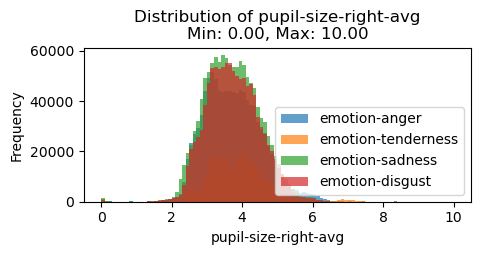

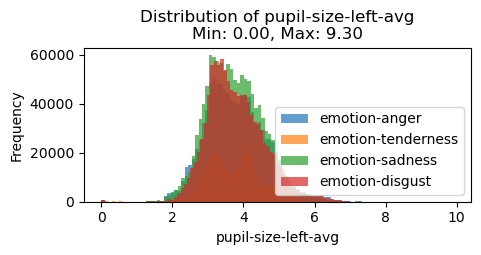

In [37]:
# plot distributions of raw signals per emotion
emotion_cols = [col for col in df.columns if "emotion" in col]
print(emotion_cols)
signals = ["x-avg", "y-avg", "pupil-size-right-avg", "pupil-size-left-avg"]
for signal in signals:
    for tresh in [5]:
        plt.figure(figsize=(5, 2))
        for emotion in emotion_cols:
            data = df.loc[df[emotion] > tresh, signal]
            min_val = data.min()
            max_val = data.max()

            # print(f"Distribution of {signal} for {emotion}:")
            # print(data.describe())
            # print("Percentage of NaN values: ",data.isna().sum()/len(data)*100)
        
            plt.hist(data, bins=100, alpha=0.7, label=emotion)
        plt.title(f"Distribution of {signal}\nMin: {min_val:.2f}, Max: {max_val:.2f}")
        plt.xlabel(signal)
        plt.ylabel("Frequency")
        plt.legend(loc='lower right')
        plt.show()


## Scatter plots: points on screen 
### Colored by emotion

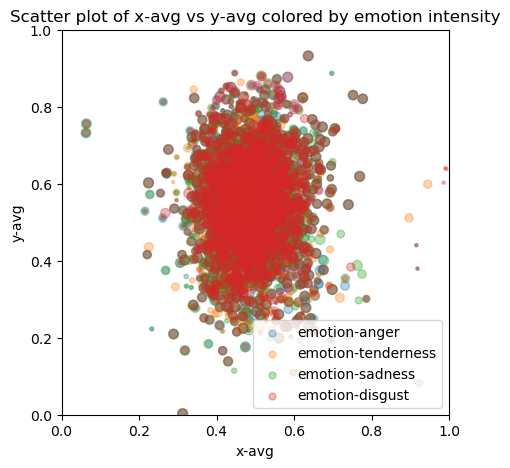

In [38]:
# scatter plot: each emotion is its own color, size according to intensity, x,y coordinates determined by "x-avg" and "y-avg"
emotion_cols = [col for col in df.columns if "emotion" in col]
# random sample to speed up plotting
df_temp = df.sample(n=5000, random_state=111)
plt.figure(figsize=(5, 5))
for emotion in emotion_cols:
    plt.scatter(df_temp["x-avg"], df_temp["y-avg"], s=df_temp[emotion]*5, alpha=0.33, label=emotion)
plt.title(f"Scatter plot of x-avg vs y-avg colored by emotion intensity")
plt.xlabel("x-avg")
plt.ylabel("y-avg")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.show()

## Plot average emotion value for pupil size bins for all emotions



emotion-anger:
Count per bin: [  20447  480735 1620868  999016  203220   37398    1206]

emotion-tenderness:
Count per bin: [  20447  480735 1620868  999016  203220   37398    1206]

emotion-sadness:
Count per bin: [  20447  480735 1620868  999016  203220   37398    1206]

emotion-disgust:
Count per bin: [  20447  480735 1620868  999016  203220   37398    1206]


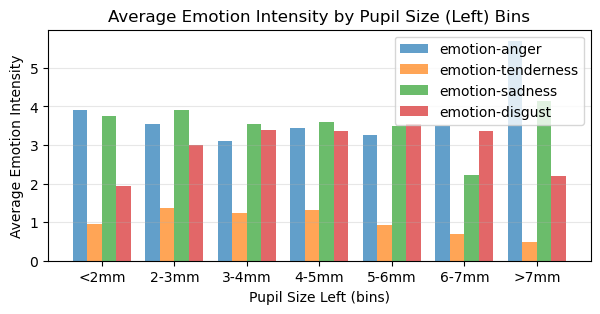

In [39]:
# plot average emotion value for pupil size bins for all emotions
# with shifted centers (side by side)

# Define pupil size bins
pupil_bins = [0, 2, 3, 4, 5, 6, 7, 10]
pupil_labels = ['<2mm', '2-3mm', '3-4mm', '4-5mm', '5-6mm', '6-7mm', '>7mm']

emotion_cols = [col for col in df.columns if "emotion" in col]

plt.figure(figsize=(7, 3))

bar_width = 0.8 / len(emotion_cols)  # Width of each emotion's bars
x_positions = np.arange(len(pupil_labels))

for idx, emotion in enumerate(emotion_cols):
    # Create a copy of the data with non-null values
    df_temp = df[['pupil-size-left-avg', emotion]].dropna()
    
    # Create bins
    df_temp['pupil_bin'] = pd.cut(df_temp['pupil-size-left-avg'], bins=pupil_bins, labels=pupil_labels, include_lowest=True)
    
    # Calculate average emotion for each bin
    avg_emotion_per_bin = df_temp.groupby('pupil_bin',observed=False)[emotion].mean()
    count_per_bin = df_temp.groupby('pupil_bin',observed=False).size()
    
    print(f"\n{emotion}:")
    # print(f"Average per bin: {avg_emotion_per_bin.values}")
    print(f"Count per bin: {count_per_bin.values}")
    
    # Shift bin centers for each emotion
    shifted_positions = x_positions + (idx - len(emotion_cols)/2 + 0.5) * bar_width
    
    # Plot bars
    plt.bar(shifted_positions, avg_emotion_per_bin.values, width=bar_width, alpha=0.7, label=emotion)

plt.xticks(x_positions, pupil_labels)
plt.xlabel('Pupil Size Left (bins)')
plt.ylabel('Average Emotion Intensity')
plt.title('Average Emotion Intensity by Pupil Size (Left) Bins')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()


## Plot average pupil size for each emotion intensity value



emotion-anger:
Count per emotion value: [1445562  225637  250231  107711  124001  179507  102999  240629  171834
  195760  319019]

emotion-tenderness:
Count per emotion value: [2456147  118045  129802  113611   75745  133709   56615  144838   79841
   33162   21375]

emotion-sadness:
Count per emotion value: [1428175  195901  171430   93332  112762  151221  135395  269970  218162
  247233  339309]

emotion-disgust:
Count per emotion value: [1646332  134104  125398  140781   98420  134303   59443  205791  215178
  227473  375667]


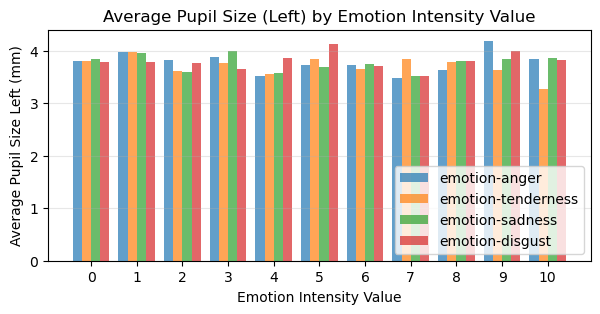

In [40]:
# plot average pupil size for each emotion intensity value
# emotion values are discrete 0-10, plot average pupil size for each emotion value

emotion_cols = [col for col in df.columns if "emotion" in col]

plt.figure(figsize=(7, 3))

bar_width = 0.8 / len(emotion_cols)  # Width of each emotion's bars
emotion_values = np.arange(0, 11)  # 0 to 10

for idx, emotion in enumerate(emotion_cols):
    # Create a copy of the data with non-null values
    df_temp = df[['pupil-size-left-avg', emotion]].dropna()
    
    # Round emotion values to integers (in case they're floats)
    df_temp[emotion] = df_temp[emotion].round().astype(int)
    
    # Calculate average pupil size for each emotion value
    avg_pupil_per_emotion = df_temp.groupby(emotion)['pupil-size-left-avg'].mean()
    count_per_emotion = df_temp.groupby(emotion).size()
    
    print(f"\n{emotion}:")
    print(f"Count per emotion value: {count_per_emotion.values}")
    
    # Reindex to include all emotion values 0-10, fill missing with NaN
    avg_pupil_per_emotion = avg_pupil_per_emotion.reindex(emotion_values)
    
    # Shift bin centers for each emotion
    shifted_positions = emotion_values + (idx - len(emotion_cols)/2 + 0.5) * bar_width
    
    # Plot bars (only where we have data)
    plt.bar(shifted_positions, avg_pupil_per_emotion.values, width=bar_width, alpha=0.7, label=emotion)

plt.xticks(emotion_values)
plt.xlabel('Emotion Intensity Value')
plt.ylabel('Average Pupil Size Left (mm)')
plt.title('Average Pupil Size (Left) by Emotion Intensity Value')
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.show()


## Emotion distributions

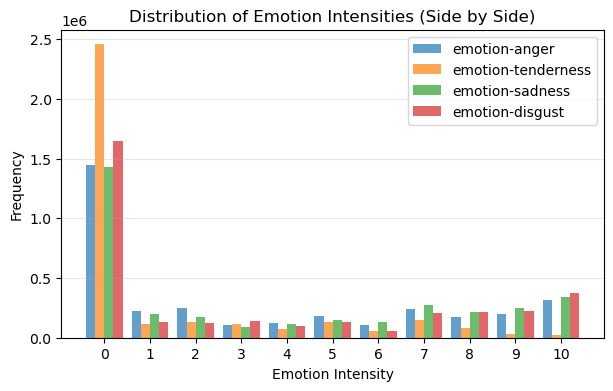

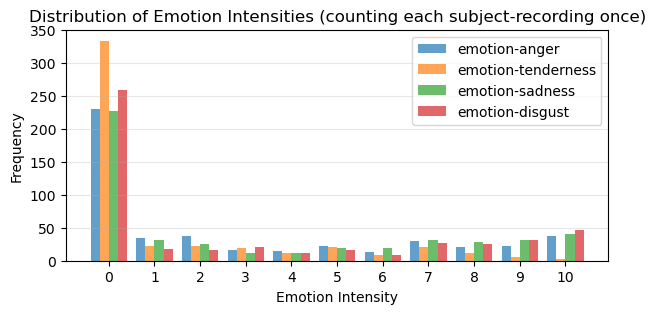

In [41]:
# =========================================================================
# plot emotion distributions
# =========================================================================
exclude_zero = 0

emotion_cols = [col for col in df.columns if "emotion" in col]
plt.figure(figsize=(7, 4))
# Define discrete bins for emotion values (1-10)
bins = np.arange(-0.5+exclude_zero, 11.5, 1)  # Creates bins centered at 1, 2, ..., 10
bar_width = 0.8 / len(emotion_cols)  # Width of each emotion's bars

for idx, emotion in enumerate(emotion_cols):
    data = df[emotion].dropna()
    min_val = data.min()
    max_val = data.max()
    
    # Calculate histogram
    counts, bin_edges = np.histogram(data, bins=bins)
    
    # Shift bin centers for each emotion
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    shifted_centers = bin_centers + (idx - len(emotion_cols)/2 + 0.5) * bar_width
    
    # Plot as bar chart
    plt.bar(shifted_centers, counts, width=bar_width, alpha=0.7, label=emotion)
    
    # print(f"{emotion}: Min={min_val:.2f}, Max={max_val:.2f}, Count={len(data)}")

plt.title(f"Distribution of Emotion Intensities (Side by Side)")
plt.xlabel("Emotion Intensity")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.xticks(range(0+exclude_zero, 11))
plt.show()

# =========================================================================
# count each (subject, recording) pair once
# =========================================================================


# keep exactly one row per (subject, recording) so each pair is counted once
df_sr = df.dropna().drop_duplicates(subset=["subject", "recording"])[["subject", "recording"] + emotion_cols]

plt.figure(figsize=(7, 3))
bins = np.arange(-0.5 + exclude_zero, 11.5, 1)  # bins centered at 1..10 (or 0..10 if exclude_zero=0)
bar_width = 0.8 / len(emotion_cols)

for idx, emotion in enumerate(emotion_cols):
    data = df_sr[emotion].dropna()
    min_val, max_val = data.min(), data.max()

    counts, bin_edges = np.histogram(data, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    shifted_centers = bin_centers + (idx - len(emotion_cols)/2 + 0.5) * bar_width

    plt.bar(shifted_centers, counts, width=bar_width, alpha=0.7, label=emotion)
    # print(f"{emotion}: Min={min_val:.2f}, Max={max_val:.2f}, Count={len(data)}")

plt.title("Distribution of Emotion Intensities (counting each subject-recording once)")
plt.xlabel("Emotion Intensity")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.xticks(range(0 + exclude_zero, 11))
plt.show()

### Emotion distr. for each subject separately
Warning: 48 plots.

In [42]:
run_this_cell = False

if run_this_cell:
    # plot emotion distributions for each subject
    exclude_zero = 0

    emotion_cols = [col for col in df.columns if "emotion" in col]
    subjects = df['subject'].unique()

    for subject in subjects:
        plt.figure(figsize=(7, 4))
        
        # keep exactly one row per (subject, recording) so each pair is counted once
        df_temp = df[df['subject'] == subject]
        df_sr = df_temp.dropna().drop_duplicates(subset=["recording"])[["recording"] + emotion_cols]

        bins = np.arange(-0.5 + exclude_zero, 11.5, 1)  # bins centered at 1..10 (or 0..10 if exclude_zero=0)
        bar_width = 0.8 / len(emotion_cols)

        for idx, emotion in enumerate(emotion_cols):
            data = df_sr[emotion].dropna()
            min_val, max_val = data.min(), data.max()

            counts, bin_edges = np.histogram(data, bins=bins)
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            shifted_centers = bin_centers + (idx - len(emotion_cols)/2 + 0.5) * bar_width

            plt.bar(shifted_centers, counts, width=bar_width, alpha=0.7, label=emotion)
            # print(f"{emotion}: Min={min_val:.2f}, Max={max_val:.2f}, Count={len(data)}")

        plt.title("Distribution of Emotion Intensities (counting each subject-recording once)")
        plt.xlabel("Emotion Intensity")
        plt.ylabel("Frequency")
        plt.grid(axis="y", alpha=0.3)
        plt.legend()
        plt.xticks(range(0 + exclude_zero, 11))
        plt.show()

### Number of Subjects by Unique Emotion Intensities Reported 

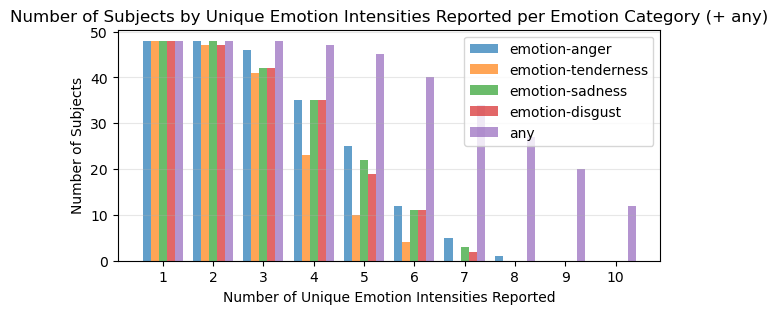

In [43]:

emotion_cols = [c for c in df.columns if "emotion" in c]
emo_plus_any = emotion_cols + ["any"]

subjects = df["subject"].unique()
max_unique_intensities = 10  # intensities 1..10
unique_intensity_counts = {e: np.zeros(max_unique_intensities, dtype=int) for e in emo_plus_any}

for subject in subjects:
    df_temp = df[df["subject"] == subject]

    # one row per recording for this subject (emotion constant per subject-recording)
    df_sr = df_temp.dropna(subset=["recording"]).drop_duplicates(subset=["recording"])[["recording"] + emotion_cols]

    # "any": total number of unique emotion values across all emotion columns & recordings for this subject
    # (values in 1..10; NaNs ignored)
    any_vals = pd.unique(df_sr[emotion_cols].to_numpy().ravel())
    any_vals = any_vals[~pd.isna(any_vals)]
    num_unique_any = len(any_vals)
    for i in range(min(num_unique_any, max_unique_intensities)):
        unique_intensity_counts["any"][i] += 1

    # per-emotion
    for emotion in emotion_cols:
        unique_intensities = df_sr[emotion].dropna().unique()
        num_unique = len(unique_intensities)
        for i in range(min(num_unique, max_unique_intensities)):
            unique_intensity_counts[emotion][i] += 1

# plot
plt.figure(figsize=(7, 3))
bar_width = 0.8 / len(emo_plus_any)
x_positions = np.arange(max_unique_intensities) + 1  # 1..10

for idx, emotion in enumerate(emo_plus_any):
    counts = unique_intensity_counts[emotion]
    shifted_positions = x_positions + (idx - len(emo_plus_any)/2 + 0.5) * bar_width
    plt.bar(shifted_positions, counts, width=bar_width, alpha=0.7, label=emotion)

plt.xticks(x_positions)
plt.xlabel("Number of Unique Emotion Intensities Reported")
plt.ylabel("Number of Subjects")
plt.title("Number of Subjects by Unique Emotion Intensities Reported per Emotion Category (+ any)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

## Number of subject-recording pairs with less than `thresh` distinct emotion intensity values

In [44]:
# how many subject, recording pairs have all emotions reported as <= thresh
# keep exactly one row per (subject, recording) so each pair is counted once
df_sr = df.dropna().drop_duplicates(subset=["subject", "recording"])[["subject", "recording"] + emotion_cols]

# check if all emotions are <= thresh for each (subject, recording) pair
thresh = 2
all_zero = (df_sr[emotion_cols] <= thresh).all(axis=1)

num_all_zero = all_zero.sum()
print(f"Number of subject-recording pairs with all emotions reported <= {thresh}: {num_all_zero}")
print(f"Subject-recording pairs with all emotions reported <= {thresh}:")
print(df_sr.loc[all_zero, ["subject", "recording"]])

Number of subject-recording pairs with all emotions reported <= 2: 116
Subject-recording pairs with all emotions reported <= 2:
         subject  recording
30101         17          9
43180         17          5
161027        16          6
206960         5         10
270957        34          3
...          ...        ...
3363103       24          9
3367432       37          3
3387353        2          9
3414761       43          9
3419051       27          3

[116 rows x 2 columns]
